<a href="https://colab.research.google.com/github/ElpoderdelComputo/Procesamiento_imagenes/blob/main/FILTROS_Y_HERRAMIENTAS_PARA_EL_PRE_PROCESO_DE_IM%C3%81GENES_DIGITALES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Autor: José Rodríguez Rosales
* Canal de YouTube: El poder del Cómputo*

# **FILTROS Y HERRAMIENTAS PARA EL PRE-PROCESO DE IMÁGENES DIGITALES**

En el análisis de imágenes, los filtros y otras herramientas juegan un papel crucial para mejorar, procesar e interpretar imágenes, especialmente cuando se trabaja con datos en bruto en investigaciones científicas, diagnósticos médicos o aplicaciones de visión por computadora. A continuación, se presenta una descripción general de los tipos comunes de filtros y herramientas, y su importancia en el análisis de imágenes:

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import urllib.request
from skimage import util
from matplotlib.patches import Rectangle

In [ ]:
# 1. CARGAR Y PREPARAR LA IMAGEN
'''
print("1. Cargando imagen de ejemplo...")
# Descargar una imagen de ejemplo
url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/baboon.jpg'
urllib.request.urlretrieve(url, 'baboon.jpg')
img = cv2.imread('/content/baboon.jpg')
'''

# Cargar la imagen en escala de grises
img = cv2.imread('/content/cameraman.png')

In [ ]:
# Añadir ruido gaussiano
img_con_ruido = util.random_noise(img, mode='gaussian', clip=True)

# Añadir ruido de sal y pimienta
img_ruido_salpimienta = util.random_noise(img, mode='s&p', clip=True)

print("Ruido gaussiano y de sal y pimienta añadidos a las imágenes y guardados en 'img_con_ruido' e 'img_ruido_salpimienta'.")

Ruido gaussiano y de sal y pimienta añadidos a las imágenes y guardados en 'img_con_ruido' e 'img_ruido_salpimienta'.


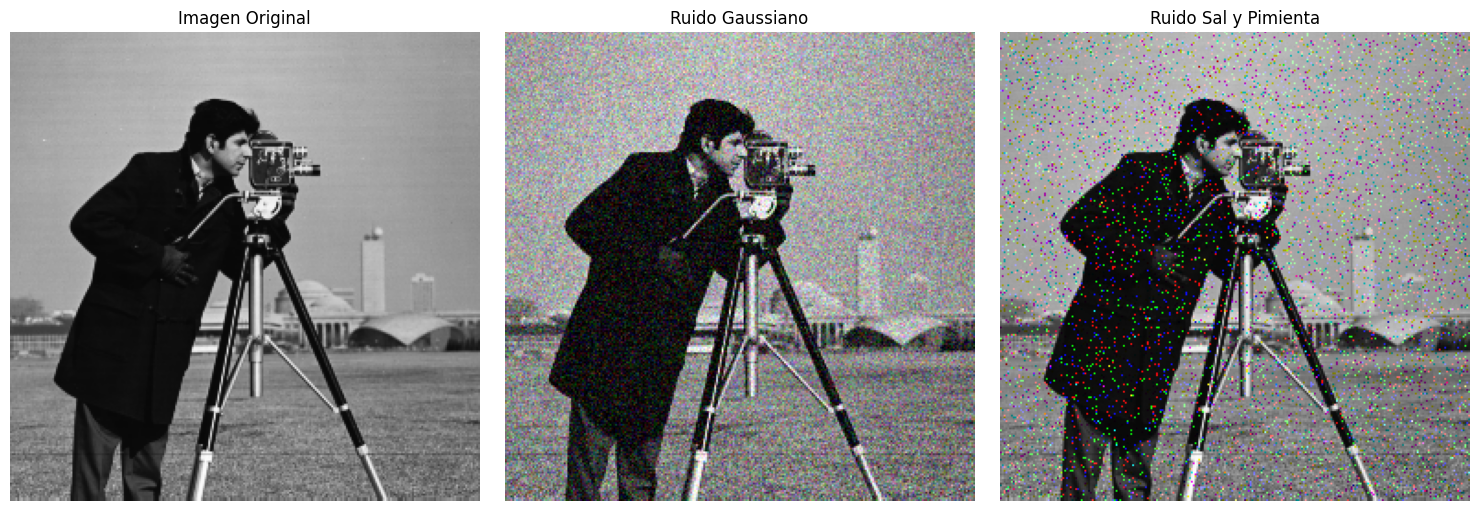

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Convertir la imagen original de BGR a RGB para mostrarla correctamente con matplotlib
img_rgb_original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

axes[0].imshow(img_rgb_original)
axes[0].set_title('Imagen Original')
axes[0].axis('off')

axes[1].imshow(img_con_ruido)
axes[1].set_title('Ruido Gaussiano')
axes[1].axis('off')

axes[2].imshow(img_ruido_salpimienta)
axes[2].set_title('Ruido Sal y Pimienta')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Entendiendo la Convolución: El Corazón de los Filtros de Imagen

La **convolución** es una operación fundamental en el procesamiento de imágenes, especialmente para el filtrado. Puedes imaginarla como una pequeña 'ventana' (nuestro **kernel** o matriz de filtro) que se desliza sobre cada píxel de tu imagen.

El proceso es el siguiente:

1.  **Deslizamiento del Kernel**: El kernel, por ejemplo, una matriz de 3x3, se posiciona sobre una región de la imagen. El píxel central del kernel se alinea con el píxel de la imagen que estamos procesando en ese momento.
2.  **Multiplicación Elemento a Elemento**: En cada posición, cada valor dentro del kernel se multiplica por el valor del píxel correspondiente que está 'debajo' en la imagen.
3.  **Suma**: Todos los resultados de estas multiplicaciones se suman. Esta suma se convierte en el nuevo valor del píxel central en la imagen de salida (la imagen filtrada).
4.  **Normalización**: Para filtros de promedio como el Box Blur, es común dividir la suma total por la cantidad de elementos en el kernel (por ejemplo, por 9 para un kernel de 3x3, o por 25 para uno de 5x5). El propósito de esta **normalización** es asegurar que la intensidad general de la imagen no cambie drásticamente. Si no dividiéramos, la imagen filtrada podría volverse demasiado brillante o demasiado oscura. Al normalizar, el rango de valores de los píxeles se mantiene similar al de la imagen original, evitando saturación o subexposición y preservando la luminosidad media.

Este proceso se repite, deslizando el kernel un píxel a la vez por toda la imagen, hasta que todos los píxeles hayan sido procesados, resultando en una nueva imagen con las características de los vecinos promediadas o modificadas según el kernel.


3. ¿QUÉ ES LA CONVOLUCIÓN?

📌 PARTE 1: El Kernel (el filtro)
----------------------------------------

Kernel de Promedio 3x3:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

💡 Cada valor es 1/9 = 0.111...
   La suma total = 1.0 (conserva el brillo)


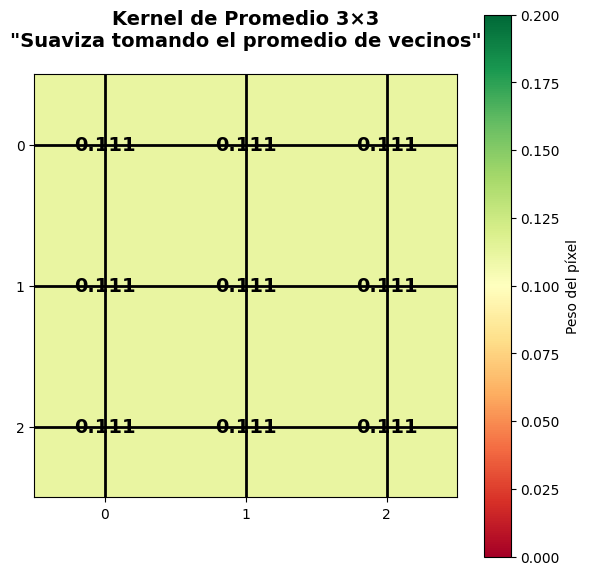


📌 PARTE 2: ¿Cómo funciona la convolución?
----------------------------------------


/tmp/ipython-input-2865329685.py:92: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


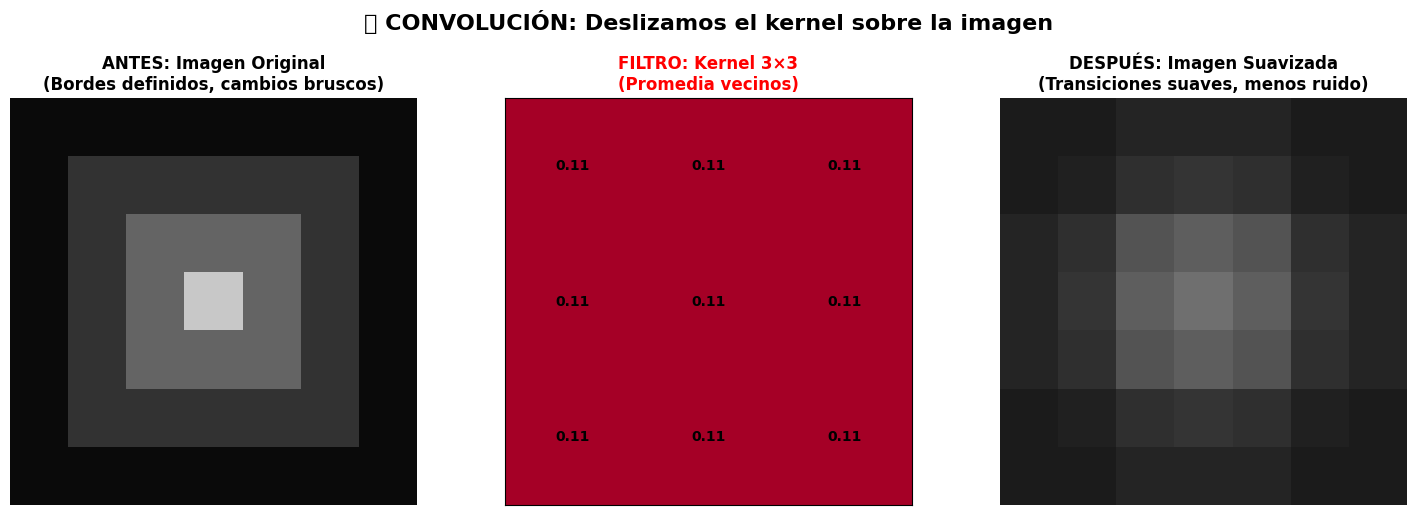


📌 PARTE 3: Efecto en imagen real
----------------------------------------


/tmp/ipython-input-2865329685.py:136: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


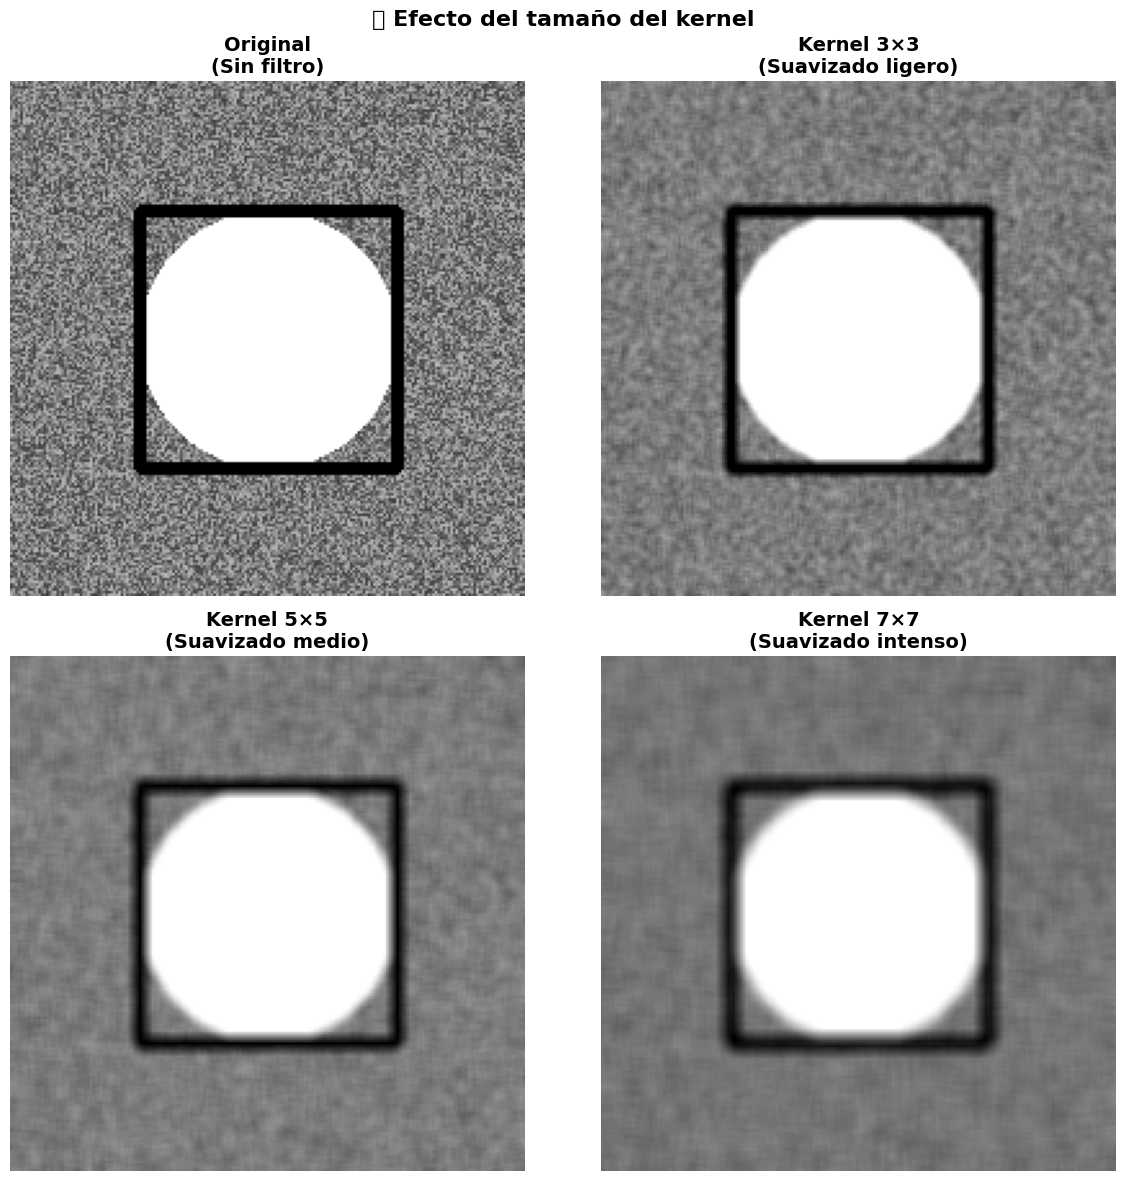


✅ RESUMEN - Convolución en 3 puntos:

1️⃣  KERNEL = Matriz pequeña con pesos
    → Define QUÉ operación hacer (suavizar, detectar bordes, etc.)

2️⃣  CONVOLUCIÓN = Deslizar el kernel sobre la imagen
    → Multiplicar y sumar valores en cada posición

3️⃣  RESULTADO = Nueva imagen transformada
    → Kernel más grande = efecto más intenso

💡 ANALOGÍA: Como pasar una esponja mojada sobre un dibujo
   • Esponja pequeña (3×3) → suavizado sutil
   • Esponja grande (7×7) → suavizado fuerte


In [ ]:
# ============================================
# 3. EXPLICACIÓN VISUAL DE LA CONVOLUCIÓN
# ============================================
print("\n" + "="*50)
print("3. ¿QUÉ ES LA CONVOLUCIÓN?")
print("="*50)

# -----------------
# PARTE 1: El Kernel
# -----------------
print("\n📌 PARTE 1: El Kernel (el filtro)")
print("-" * 40)

# Crear kernel simple 3x3
kernel_3x3 = np.ones((3,3), np.float32) / 9

print("\nKernel de Promedio 3x3:")
print(kernel_3x3)
print("\n💡 Cada valor es 1/9 = 0.111...")
print("   La suma total = 1.0 (conserva el brillo)")

# Visualización del kernel
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(kernel_3x3, cmap='RdYlGn', interpolation='nearest', vmin=0, vmax=0.2)

# Agregar grid y valores
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.grid(True, color='black', linewidth=2)
ax.set_title('Kernel de Promedio 3×3\n"Suaviza tomando el promedio de vecinos"',
             fontsize=14, fontweight='bold', pad=20)

# Valores en las celdas
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{kernel_3x3[i,j]:.3f}',
                ha='center', va='center',
                color='black', fontweight='bold', fontsize=14)

plt.colorbar(im, ax=ax, label='Peso del píxel')
plt.tight_layout()
plt.show()

# -----------------
# PARTE 2: Proceso de Convolución Paso a Paso
# -----------------
print("\n📌 PARTE 2: ¿Cómo funciona la convolución?")
print("-" * 40)

# Crear imagen simple para demostración
img_demo = np.array([
    [10, 10, 10, 10, 10, 10, 10],
    [10, 50, 50, 50, 50, 50, 10],
    [10, 50, 100, 100, 100, 50, 10],
    [10, 50, 100, 200, 100, 50, 10],
    [10, 50, 100, 100, 100, 50, 10],
    [10, 50, 50, 50, 50, 50, 10],
    [10, 10, 10, 10, 10, 10, 10]
], dtype=np.float32)

# Aplicar convolución
img_suavizada = cv2.filter2D(img_demo, -1, kernel_3x3)

# Visualización lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Imagen original
axes[0].imshow(img_demo, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('ANTES: Imagen Original\n(Bordes definidos, cambios bruscos)',
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

# Kernel
axes[1].imshow(kernel_3x3, cmap='RdYlGn', interpolation='nearest')
axes[1].set_title('FILTRO: Kernel 3×3\n(Promedia vecinos)',
                  fontsize=12, fontweight='bold', color='red')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{kernel_3x3[i,j]:.2f}',
                    ha='center', va='center', fontsize=10, fontweight='bold')
axes[1].set_xticks([])
axes[1].set_yticks([])

# Imagen suavizada
axes[2].imshow(img_suavizada, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('DESPUÉS: Imagen Suavizada\n(Transiciones suaves, menos ruido)',
                  fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.suptitle('🎯 CONVOLUCIÓN: Deslizamos el kernel sobre la imagen',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# -----------------
# PARTE 3: Comparación con Imagen Real
# -----------------
print("\n📌 PARTE 3: Efecto en imagen real")
print("-" * 40)

# Cargar una imagen de prueba (o usar una de ejemplo)
# Si no tienes imagen, creamos una con ruido
img_real = np.random.randint(100, 200, (200, 200), dtype=np.uint8)
# Agregar algunas características
cv2.circle(img_real, (100, 100), 50, 255, -1)
cv2.rectangle(img_real, (50, 50), (150, 150), 50, 3)

# Aplicar diferentes niveles de suavizado
kernel_5x5 = np.ones((5, 5), np.float32) / 25
kernel_7x7 = np.ones((7, 7), np.float32) / 49

img_suave_3 = cv2.filter2D(img_real, -1, kernel_3x3)
img_suave_5 = cv2.filter2D(img_real, -1, kernel_5x5)
img_suave_7 = cv2.filter2D(img_real, -1, kernel_7x7)

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(img_real, cmap='gray')
axes[0, 0].set_title('Original\n(Sin filtro)', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_suave_3, cmap='gray')
axes[0, 1].set_title('Kernel 3×3\n(Suavizado ligero)', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_suave_5, cmap='gray')
axes[1, 0].set_title('Kernel 5×5\n(Suavizado medio)', fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_suave_7, cmap='gray')
axes[1, 1].set_title('Kernel 7×7\n(Suavizado intenso)', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle('🔍 Efecto del tamaño del kernel', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# -----------------
# RESUMEN
# -----------------
print("\n" + "="*50)
print("✅ RESUMEN - Convolución en 3 puntos:")
print("="*50)
print("\n1️⃣  KERNEL = Matriz pequeña con pesos")
print("    → Define QUÉ operación hacer (suavizar, detectar bordes, etc.)")
print("\n2️⃣  CONVOLUCIÓN = Deslizar el kernel sobre la imagen")
print("    → Multiplicar y sumar valores en cada posición")
print("\n3️⃣  RESULTADO = Nueva imagen transformada")
print("    → Kernel más grande = efecto más intenso")
print("\n💡 ANALOGÍA: Como pasar una esponja mojada sobre un dibujo")
print("   • Esponja pequeña (3×3) → suavizado sutil")
print("   • Esponja grande (7×7) → suavizado fuerte")
print("="*50)

# FILTROS ESCENCIALES
## 1. Filtros de Suavizado (Desenfoque)
- **Tipos**: Filtro Gaussiano (gaussian_blur), filtro de mediana (median_blur), filtro de promedio
- **Propósito**: Estos filtros reducen el ruido y los detalles en una imagen. A menudo se utilizan en el preprocesamiento para eliminar ruido aleatorio mientras se preservan características importantes, como los bordes.
- **Importancia**: El suavizado ayuda a mejorar la claridad de las características clave de la imagen, lo que facilita el análisis posterior, como la detección de objetos o la segmentación.

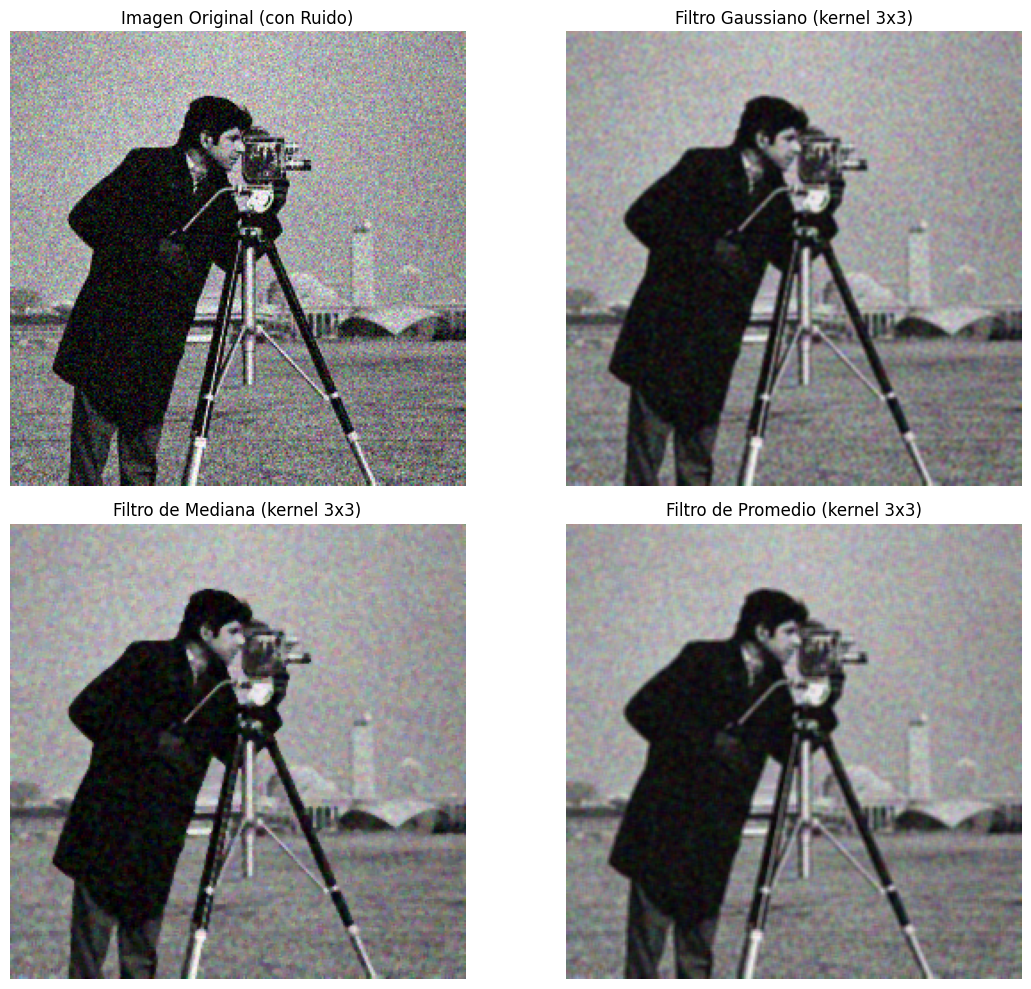


FILTROS DE SUAVIZADO - EXPLICACIÓN:
• Filtro Gaussiano: Aplica un desenfoque usando una función gaussiana,
  dando más peso a los píxeles centrales. Excelente para eliminar ruido gaussiano.

• Filtro de Mediana: Reemplaza cada píxel por la mediana de los píxeles vecinos.
  Muy efectivo para eliminar ruido "sal y pimienta".

• Filtro de Promedio: Reemplaza cada píxel por el promedio de los píxeles vecinos.
  Simple pero efectivo para ruido uniforme.



In [ ]:
# Crear figura para mostrar resultados
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Convertir la imagen con ruido (que es float) a uint8 (0-255) para las funciones de OpenCV
# y para una visualización consistente con imshow
img_con_ruido_uint8 = (img_con_ruido * 255).astype(np.uint8)

# Imagen original (con ruido gaussiano, ya convertida a uint8 para visualización)
axes[0,0].imshow(img_con_ruido_uint8)
axes[0,0].set_title('Imagen Original (con Ruido)')
axes[0,0].axis('off')

# Filtro Gaussiano
guassian_blur = cv2.GaussianBlur(img_con_ruido_uint8, (3, 3), 0)
axes[0,1].imshow(guassian_blur)
axes[0,1].set_title('Filtro Gaussiano (kernel 3x3)')
axes[0,1].axis('off')

# Filtro de Mediana
median_blur = cv2.medianBlur(img_con_ruido_uint8, 3)
axes[1,0].imshow(median_blur)
axes[1,0].set_title('Filtro de Mediana (kernel 3x3)')
axes[1,0].axis('off')

# Filtro de Promedio
average_blur = cv2.blur(img_con_ruido_uint8, (3, 3))
axes[1,1].imshow(average_blur)
axes[1,1].set_title('Filtro de Promedio (kernel 3x3)')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

# Explicación educativa
print("""
FILTROS DE SUAVIZADO - EXPLICACIÓN:
• Filtro Gaussiano: Aplica un desenfoque usando una función gaussiana,
  dando más peso a los píxeles centrales. Excelente para eliminar ruido gaussiano.

• Filtro de Mediana: Reemplaza cada píxel por la mediana de los píxeles vecinos.
  Muy efectivo para eliminar ruido "sal y pimienta".

• Filtro de Promedio: Reemplaza cada píxel por el promedio de los píxeles vecinos.
  Simple pero efectivo para ruido uniforme.
""")

## 2. Filtros de Enfoque (Afilado)
- **Tipos**: Filtro Laplaciano (laplace_filter), filtro de máscara de desenfoque, filtro pasa-altos
- **Propósito**: El enfoque mejora los bordes y los detalles finos al resaltar áreas de cambio rápido de intensidad.
- **Importancia**: Estos filtros ayudan a enfatizar características importantes, facilitando la detección de límites y estructuras en la imagen.


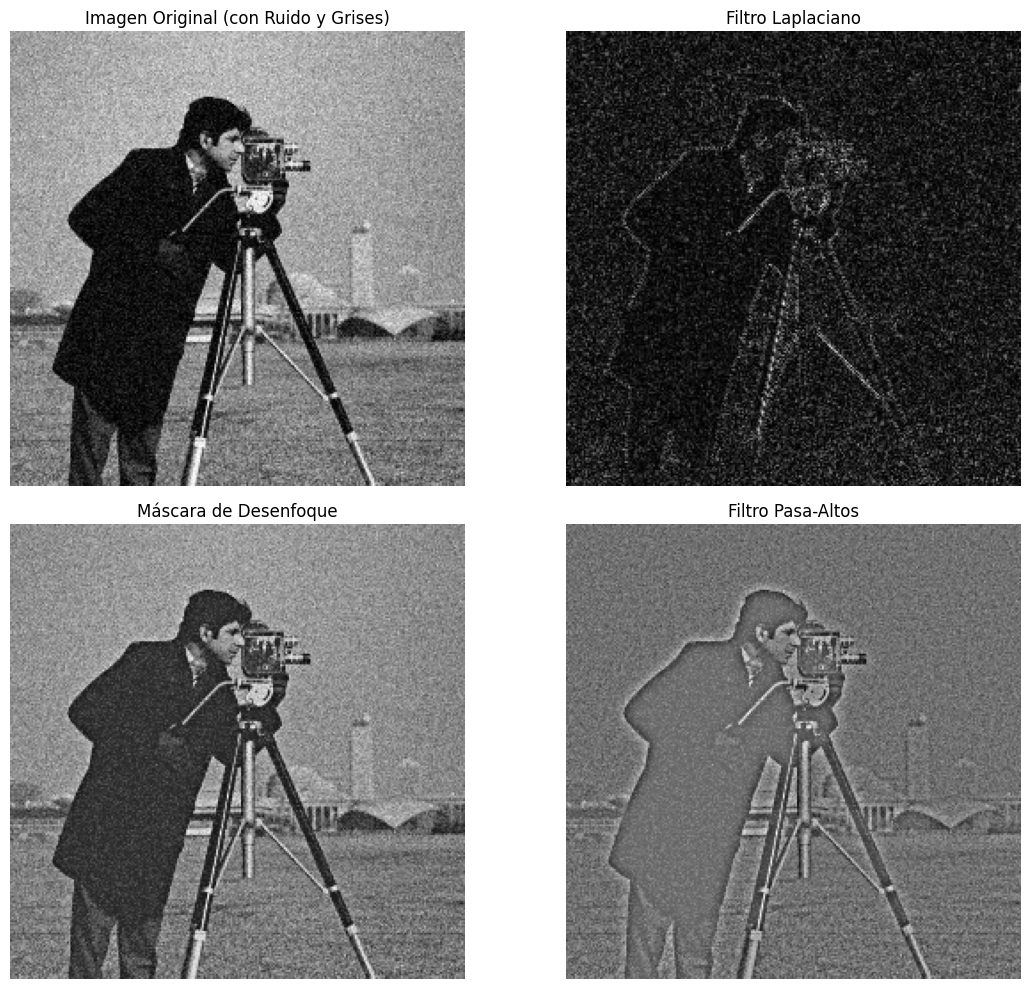


FILTROS DE ENFOQUE - EXPLICACIÓN:
• Filtro Laplaciano: Resalta regiones de rápida variación de intensidad.
  Detecta bordes en todas las direcciones.

• Máscara de Desenfoque: Técnica que resta una versión desenfocada de la imagen
  a la original para realzar bordes y detalles.

• Filtro Pasa-Altos: Permite pasar altas frecuencias (bordes y detalles)
  mientras atenúa bajas frecuencias (áreas uniformes).



In [ ]:
# Crear figura para mostrar resultados
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Convertir img_con_ruido (float RGB 0-1) a escala de grises (float 0-1) para consistencia
img_con_ruido_display = (img_con_ruido * 255).astype(np.uint8) # Convertir a uint8 para cv2.cvtColor
# Aseguramos que la imagen en escala de grises sea float64 para cv2.Laplacian
img_con_ruido_gray_float = cv2.cvtColor(img_con_ruido_display,
                                        cv2.COLOR_RGB2GRAY).astype(np.float64) / 255.0 # Cambiado a float64

# Imagen original (con ruido y en escala de grises)
axes[0,0].imshow(img_con_ruido_gray_float, cmap='gray')
axes[0,0].set_title('Imagen Original (con Ruido y Grises)')
axes[0,0].axis('off')

# Filtro Laplaciano
# Usamos CV_64F para capturar bordes negativos y positivos
laplacian = cv2.Laplacian(img_con_ruido_gray_float, cv2.CV_64F)
# MEJORA: Visualizamos el valor absoluto para ver los bordes claramente
laplacian_display = np.abs(laplacian)
# Opcional: Normalizar para visualizar mejor el contraste
laplacian_display = cv2.normalize(laplacian_display, None, 0, 1, cv2.NORM_MINMAX)

axes[0,1].imshow(laplacian_display, cmap='gray')
axes[0,1].set_title('Filtro Laplaciano')
axes[0,1].axis('off')

# Máscara de desenfoque (Unsharp Masking)
# Aplicar desenfoque Gaussiano a la imagen en escala de grises flotante
gaussian_blurred_gray = cv2.GaussianBlur(img_con_ruido_gray_float, (0, 0), 3.0)
# Usar la imagen en escala de grises flotante para addWeighted
unsharp_mask_gray = cv2.addWeighted(img_con_ruido_gray_float, 1.5, gaussian_blurred_gray, -0.5, 0)
axes[1,0].imshow(unsharp_mask_gray, cmap='gray')
axes[1,0].set_title('Máscara de Desenfoque')
axes[1,0].axis('off')

# Filtro Pasa-Altos
# Una forma simple de un filtro pasa-altos es restar una versión suavizada de la imagen de la original
highpass_gray = img_con_ruido_gray_float - gaussian_blurred_gray
# Normalizar para visualización si hay valores fuera del rango [0,1]
highpass_gray = cv2.normalize(highpass_gray, None, 0, 1, cv2.NORM_MINMAX)

axes[1,1].imshow(highpass_gray, cmap='gray')
axes[1,1].set_title('Filtro Pasa-Altos')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

print("""
FILTROS DE ENFOQUE - EXPLICACIÓN:
• Filtro Laplaciano: Resalta regiones de rápida variación de intensidad.
  Detecta bordes en todas las direcciones.

• Máscara de Desenfoque: Técnica que resta una versión desenfocada de la imagen
  a la original para realzar bordes y detalles.

• Filtro Pasa-Altos: Permite pasar altas frecuencias (bordes y detalles)
  mientras atenúa bajas frecuencias (áreas uniformes).
""")

## 3. Filtros de Detección de Bordes
- **Tipos**: Filtro Sobel (sobel_filter), detector de bordes Canny(Canny_edge_detect), filtro Prewitt
- **Propósito**: Se utilizan para identificar puntos en una imagen donde la intensidad de los píxeles cambia significativamente, lo que a menudo corresponde a los bordes de objetos o características clave.
- **Importancia**: Crucial para el reconocimiento de objetos, segmentación y extracción de características. Los bordes ayudan a definir formas y son esenciales para comprender la estructura de los objetos en una imagen.

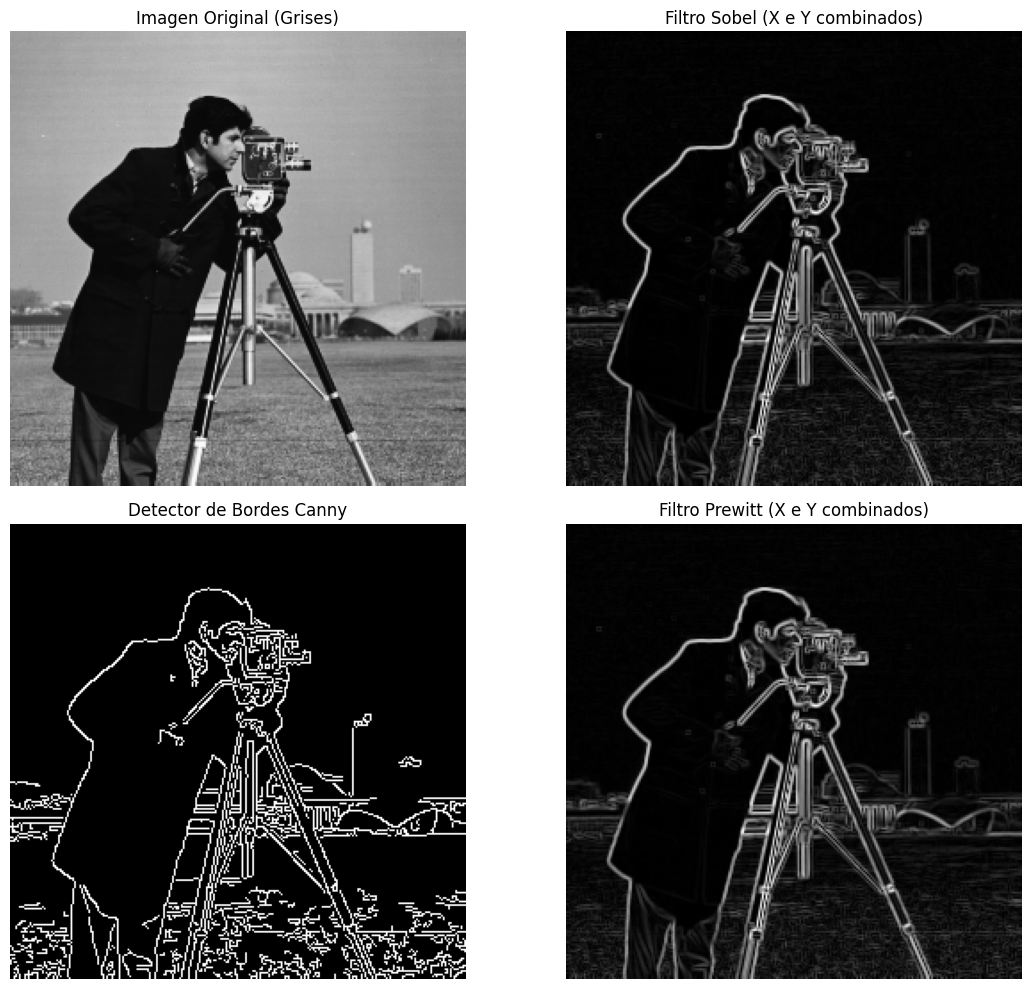


DETECCIÓN DE BORDES - EXPLICACIÓN:
• Filtro Sobel: Calcula el gradiente de la imagen en direcciones X e Y.
  Efectivo para detectar bordes horizontales y verticales.

• Detector Canny: Algoritmo multi-etapa que incluye:
  1. Reducción de ruido
  2. Cálculo del gradiente
  3. Supresión de no máximos
  4. Umbralización con histéresis
  Considerado uno de los mejores detectores de bordes.

• Filtro Prewitt: Similar a Sobel pero con kernels diferentes.
  Menos sensible al ruido que Sobel.



In [ ]:
# Crear figura para mostrar resultados
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Imagen original (grayscale para consistencia con filtros de borde)
axes[0,0].imshow(img, cmap='gray')
axes[0,0].set_title('Imagen Original (Grises)')
axes[0,0].axis('off')

# Filtro Sobel
# Se aplica sobre la imagen en escala de grises
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = np.sqrt(sobelx**2 + sobely**2)

# Normalizar Sobel para mostrar
sobel_display = cv2.normalize(sobel_combined, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
axes[0,1].imshow(sobel_display, cmap='gray')
axes[0,1].set_title('Filtro Sobel (X e Y combinados)')
axes[0,1].axis('off')

# Detector Canny
# Se aplica sobre la imagen en escala de grises (Canny ya lo hace internamente si es BGR)
canny_edges = cv2.Canny(img, 100, 200)  #treshold
axes[1,0].imshow(canny_edges, cmap='gray')
axes[1,0].set_title('Detector de Bordes Canny')
axes[1,0].axis('off')

# Filtro Prewitt
kernel_prewitt_x = np.array([[-1, 0, 1],
                            [-1, 0, 1],
                            [-1, 0, 1]])
kernel_prewitt_y = np.array([[-1, -1, -1],
                            [0, 0, 0],
                            [1, 1, 1]])
# Se aplica sobre la imagen en escala de grises y se especifica ddepth para float64
prewitt_x = cv2.filter2D(img, cv2.CV_64F, kernel_prewitt_x)
prewitt_y = cv2.filter2D(img, cv2.CV_64F, kernel_prewitt_y)
prewitt_combined = np.sqrt(prewitt_x**2 + prewitt_y**2)
# Normalizar Prewitt para mostrar
prewitt_display = cv2.normalize(prewitt_combined, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
axes[1,1].imshow(prewitt_display, cmap='gray')
axes[1,1].set_title('Filtro Prewitt (X e Y combinados)')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

print("""
DETECCIÓN DE BORDES - EXPLICACIÓN:
• Filtro Sobel: Calcula el gradiente de la imagen en direcciones X e Y.
  Efectivo para detectar bordes horizontales y verticales.

• Detector Canny: Algoritmo multi-etapa que incluye:
  1. Reducción de ruido
  2. Cálculo del gradiente
  3. Supresión de no máximos
  4. Umbralización con histéresis
  Considerado uno de los mejores detectores de bordes.

• Filtro Prewitt: Similar a Sobel pero con kernels diferentes.
  Menos sensible al ruido que Sobel.
""")

## 4. Umbralización (Thresholding)
- **Tipos**: Global, adaptativo, binario (threshold_binary), método de Otsu (threshold_otsu), textura (theshold_texture),  gaussiano (threshold_gaussian) y otros
- **Propósito**: La umbralización convierte imágenes en escala de grises en imágenes binarias, donde los píxeles se clasifican como primer plano o fondo en función de un umbral de intensidad de píxeles.
- **Importancia**: A menudo se utiliza para segmentar objetos del fondo, lo que simplifica el análisis de áreas específicas de interés en una imagen.

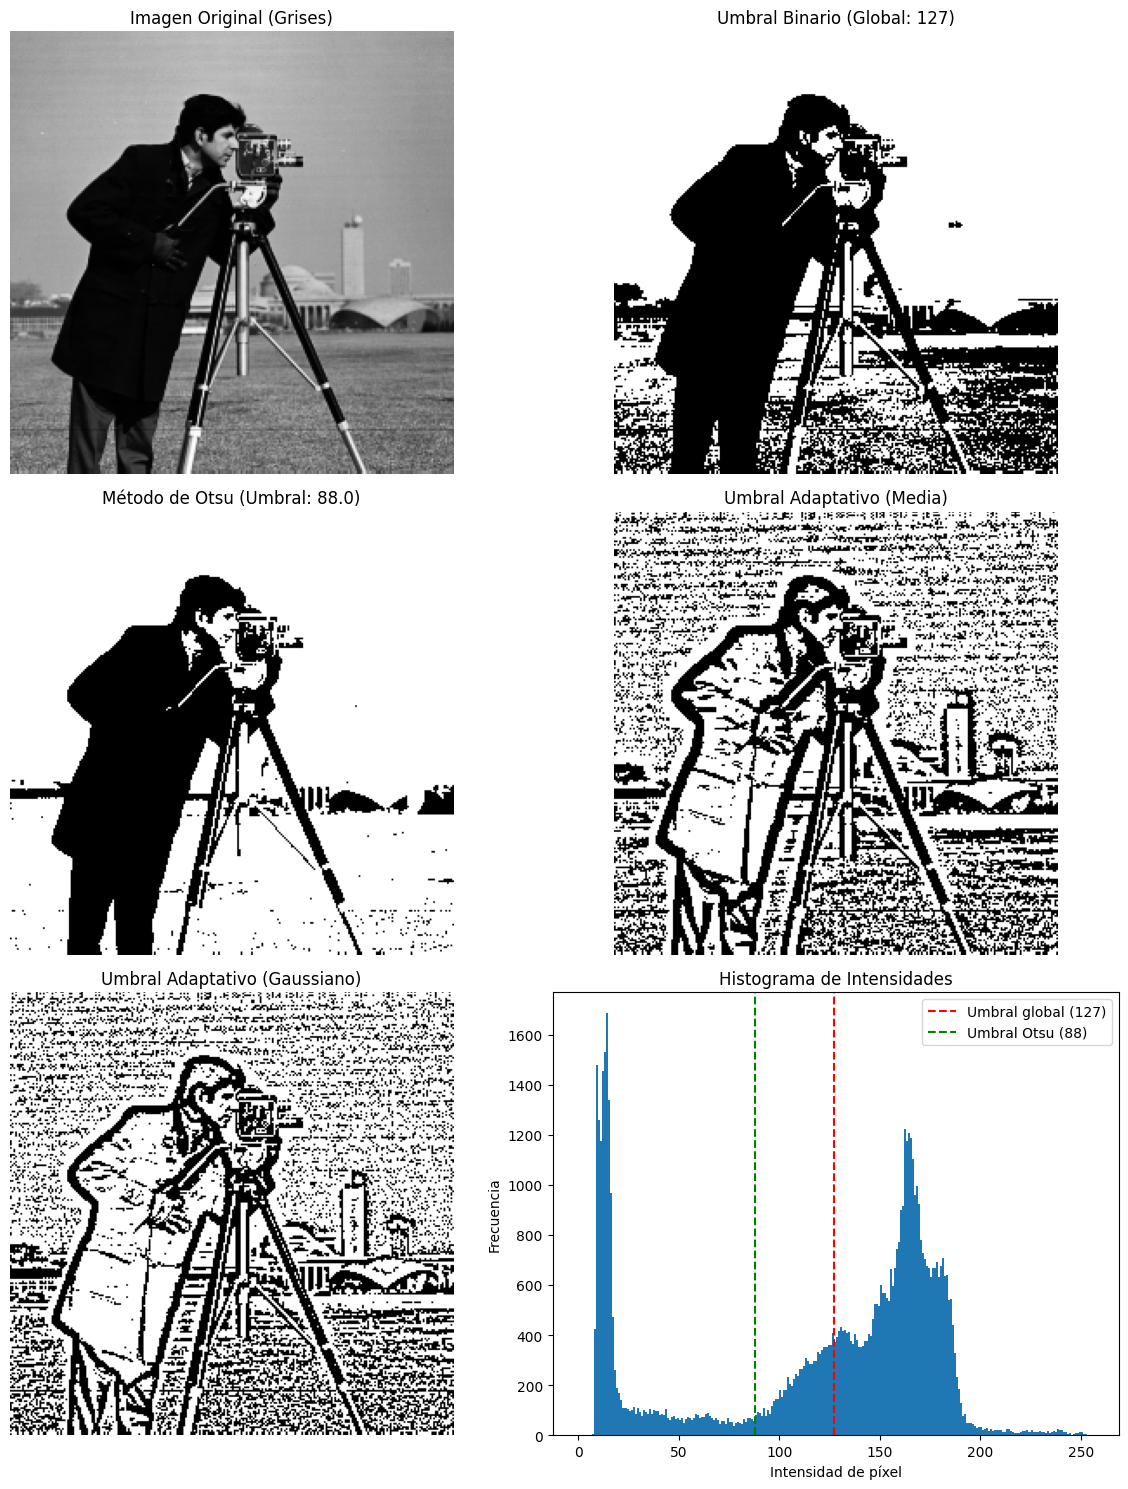


UMBRALIZACIÓN - EXPLICACIÓN:
• Umbralización Global: Usa un valor fijo para toda la imagen.
  Simple pero no funciona bien con iluminación variable.

• Método de Otsu: Determina automáticamente el umbral óptimo basado en
  el histograma de la imagen. Ideal para imágenes bimodales.

• Umbralización Adaptativa: Calcula umbrales diferentes para diferentes
  regiones de la imagen. Útil para imágenes con iluminación no uniforme.

• Umbral Gaussiano: Similar al adaptativo pero usa una ponderación gaussiana
  para calcular el umbral local.



In [ ]:
# Crear figura para mostrar resultados
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

# Asegurarse de que tenemos una versión en escala de grises para la umbralización
# Si img_gray ya está definida globalmente, se usa esa. Si no, se convierte aquí.
if 'img_gray' not in locals():
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Imagen original en grises
axes[0,0].imshow(img_gray, cmap='gray')
axes[0,0].set_title('Imagen Original (Grises)')
axes[0,0].axis('off')

# Umbralización Global Binaria
_, thresh_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
axes[0,1].imshow(thresh_binary, cmap='gray')
axes[0,1].set_title('Umbral Binario (Global: 127)')
axes[0,1].axis('off')

# Método de Otsu
_, thresh_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
axes[1,0].imshow(thresh_otsu, cmap='gray')
axes[1,0].set_title(f'Método de Otsu (Umbral: {_})')
axes[1,0].axis('off')

# Umbralización Adaptativa (Media)
thresh_adaptive_mean = cv2.adaptiveThreshold(img_gray, 255,
                                           cv2.ADAPTIVE_THRESH_MEAN_C,
                                           cv2.THRESH_BINARY, 11, 2)
axes[1,1].imshow(thresh_adaptive_mean, cmap='gray')
axes[1,1].set_title('Umbral Adaptativo (Media)')
axes[1,1].axis('off')

# Umbralización Adaptativa (Gaussiana)
thresh_adaptive_gaussian = cv2.adaptiveThreshold(img_gray, 255,
                                               cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                               cv2.THRESH_BINARY, 11, 2)
axes[2,0].imshow(thresh_adaptive_gaussian, cmap='gray')
axes[2,0].set_title('Umbral Adaptativo (Gaussiano)')
axes[2,0].axis('off')

# Mostrar histograma para entender la umbralización
axes[2,1].hist(img_gray.ravel(), bins=256, range=[0, 256])
axes[2,1].set_title('Histograma de Intensidades')
axes[2,1].set_xlabel('Intensidad de píxel')
axes[2,1].set_ylabel('Frecuencia')
axes[2,1].axvline(x=127, color='r', linestyle='--', label='Umbral global (127)')
if '_' in locals():
    axes[2,1].axvline(x=_, color='g', linestyle='--', label=f'Umbral Otsu ({int(_)})')
axes[2,1].legend()

plt.tight_layout()
plt.show()

print("""
UMBRALIZACIÓN - EXPLICACIÓN:
• Umbralización Global: Usa un valor fijo para toda la imagen.
  Simple pero no funciona bien con iluminación variable.

• Método de Otsu: Determina automáticamente el umbral óptimo basado en
  el histograma de la imagen. Ideal para imágenes bimodales.

• Umbralización Adaptativa: Calcula umbrales diferentes para diferentes
  regiones de la imagen. Útil para imágenes con iluminación no uniforme.

• Umbral Gaussiano: Similar al adaptativo pero usa una ponderación gaussiana
  para calcular el umbral local.
""")


EJEMPLO PRÁCTICO: Limpiando imagen con ruido mixto
ANÁLISIS: La imagen tiene ruido gaussiano + sal y pimienta
ESTRATEGIA: Usar filtro de mediana para sal-pimienta + gaussiano para suavizado


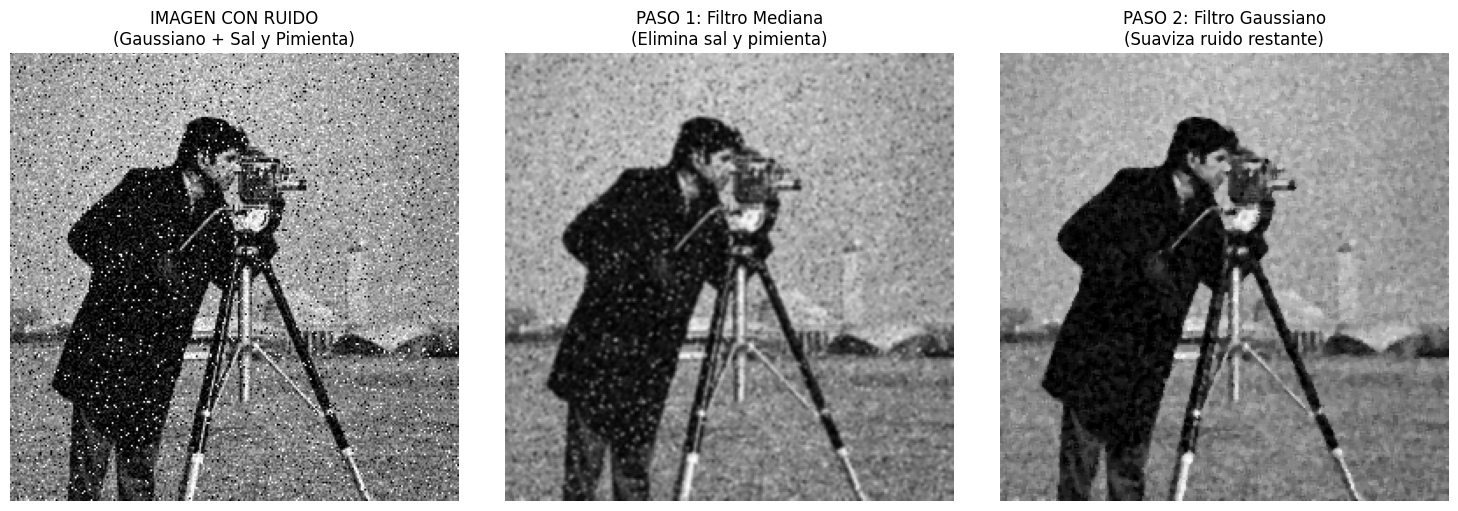

✅ RESULTADO: Imagen limpiada exitosamente en 2 pasos


In [ ]:
# --- EJEMPLO PRÁCTICO: LIMPIANDO UNA IMAGEN CON RUIDO ---
print("\n" + "="*60)
print("EJEMPLO PRÁCTICO: Limpiando imagen con ruido mixto")
print("="*60)

# Crear una imagen con ruido mixto (más realista)
img_limpia = cv2.imread('/content/cameraman.png')
img_limpia_gray = cv2.cvtColor(img_limpia, cv2.COLOR_BGR2GRAY)

# Añadir ruido mixto (gaussiano + sal y pimienta)
img_ruido_mixto = util.random_noise(img_limpia_gray, mode='gaussian', var=0.01)
img_ruido_mixto = util.random_noise(img_ruido_mixto, mode='s&p', amount=0.05)
img_ruido_mixto = (img_ruido_mixto * 255).astype(np.uint8)

# Estrategia de limpieza según el tipo de ruido
print("ANÁLISIS: La imagen tiene ruido gaussiano + sal y pimienta")
print("ESTRATEGIA: Usar filtro de mediana para sal-pimienta + gaussiano para suavizado")

# Paso 1: Eliminar ruido gaussiano restante ruido sal y pimienta con mediana
img_limpia_paso1 = cv2.GaussianBlur(img_ruido_mixto, (3, 3), 0)
# Paso 2: Suavizar ruido sal y pimienta con mediana restante
img_limpia_paso2 = cv2.medianBlur(img_ruido_mixto, 3)

# Mostrar resultados
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_ruido_mixto, cmap='gray')
axes[0].set_title('IMAGEN CON RUIDO\n(Gaussiano + Sal y Pimienta)')
axes[0].axis('off')

axes[1].imshow(img_limpia_paso1, cmap='gray')
axes[1].set_title('PASO 1: Filtro Mediana\n(Elimina sal y pimienta)')
axes[1].axis('off')

axes[2].imshow(img_limpia_paso2, cmap='gray')
axes[2].set_title('PASO 2: Filtro Gaussiano\n(Suaviza ruido restante)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("✅ RESULTADO: Imagen limpiada exitosamente en 2 pasos")